In [1]:
!pip install --quiet yfinance

In [2]:
!pip install pandas_datareader

In [3]:
import sys
!{sys.executable} -m pip install matplotlib

In [4]:
import sys
!{sys.executable} -m pip install seaborn

In [5]:
import sys
!{sys.executable} -m pip install scipy

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr
import datetime as dt
from scipy import stats
import yfinance as yf
import time

sns.set_style('whitegrid')
%matplotlib inline

In [7]:
# Define portfolio and time range
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
weights = np.array([0.25, 0.25, 0.25, 0.25])
start = dt.datetime(2020, 1, 1)
end = dt.datetime.today()

# Initialize empty dataframe
prices = pd.DataFrame()

# Fetch data for each ticker
for ticker in tickers:
    print(f"Fetching {ticker}...", end=" ")
    try:
        df = yf.Ticker(ticker).history(
            start=start.strftime('%Y-%m-%d'),
            end=end.strftime('%Y-%m-%d'),
            auto_adjust=True
        )
        series = df['Close'].rename(ticker)  # Column name should be 'Close' with a capital C
        print("✔ yfinance")
    except Exception as e:
        print(f"✖ yfinance ({e}); falling back to Stooq", end=" ")
        try:
            df2 = pdr.DataReader(ticker, 'stooq', start, end)
            df2 = df2.sort_index()
            series = df2['Close'].rename(ticker)  # Also use 'Close' here
            print("✔ Stooq")
        except Exception as e2:
            print(f"✖ Stooq failed too ({e2})")
            continue  # Skip ticker if both failed

    # Add to prices DataFrame (auto aligns on date index)
    prices = pd.concat([prices, series], axis=1)
    time.sleep(1)

# Fill any gaps
prices = prices.dropna(how='all').ffill().bfill()

# Sanity check output
print(prices.tail())


Fetching AAPL... ✔ yfinance
Fetching MSFT... ✔ yfinance
Fetching GOOGL... ✔ yfinance
Fetching AMZN... ✔ yfinance
                                 AAPL        MSFT       GOOGL        AMZN
2025-06-26 00:00:00-04:00  201.000000  497.450012  173.539993  217.119995
2025-06-27 00:00:00-04:00  201.080002  495.940002  178.529999  223.300003
2025-06-30 00:00:00-04:00  205.169998  497.410004  176.229996  219.389999
2025-07-01 00:00:00-04:00  207.820007  492.049988  175.839996  220.460007
2025-07-02 00:00:00-04:00  212.440002  491.089996  178.639999  219.919998


# Questions for Report

1. What was the main goal of this project and how did you achieve it?
ANS) To quantify the 1-day 95% Value at Risk (VaR) for a four-stock portfolio by analyzing historical return data, performing statistical tests, fitting distributions, and measuring downside risk.

2. Which tools and libraries did you use in this project, and what was the role of each? 
ANS) Tools Used
- Pandas: Data cleaning and manipulation
- yfinance: Fetch historical stock prices
- Matplotlib & Seaborn: Data visualization
- scipy.stats: Distribution fitting and hypothesis testing

3. How did you calculate Value at Risk (VaR), and what does it tell us about financial risk?
ANS) VaR estimates the worst expected loss on a portfolio at a given confidence level. For example, 1-day 95% VaR tells you there's a 5% chance of losing more than the calculated amount in one day.

4. What challenges or errors did you face while completing this project, and how did you overcome them?
ANS) Challenges
- Handling missing data from yfinance
- Understanding statistical fitting concepts (e.g. Student’s t-distribution)
- Overcoming errors during bootstrapping and drawdown calculations

5. If you were to expand this project, what would you add or change?
ANS) 
- Add sector analysis
- Incorporate Monte Carlo simulation
- Expand stock universe or analyze rolling multi-day VaR


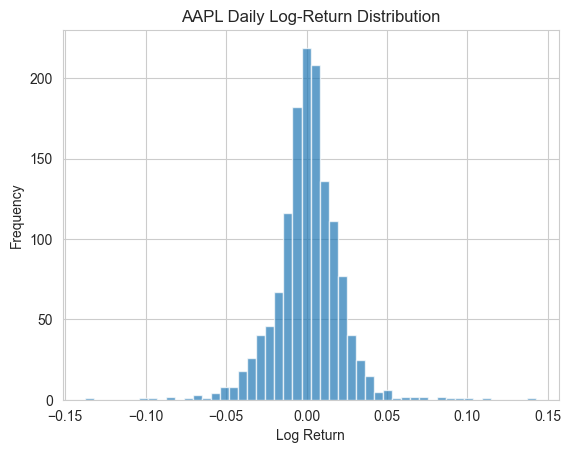

In [8]:
# Compute daily log returns
logR = np.log(prices / prices.shift(1))

# Now you can plot the histogram for AAPL
logR['AAPL'].hist(bins=50, alpha=0.7)
plt.title('AAPL Daily Log-Return Distribution')  # Adjusted title to match the ticker being plotted
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
 

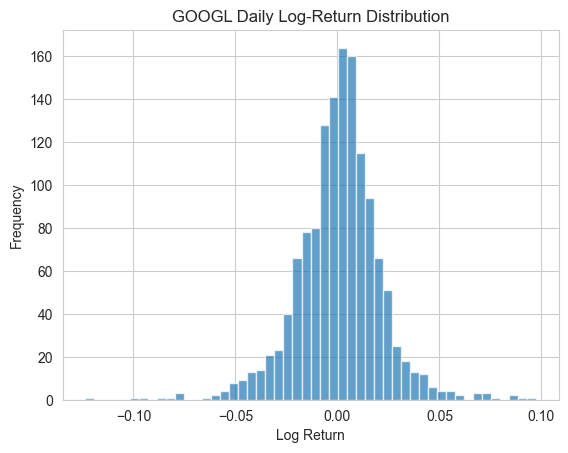

In [9]:
# Compute daily log returns
logR = np.log(prices / prices.shift(1))

# Now you can plot the histogram for AAPL
logR['GOOGL'].hist(bins=50, alpha=0.7)
plt.title('GOOGL Daily Log-Return Distribution')  # Adjusted title to match the ticker being plotted
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


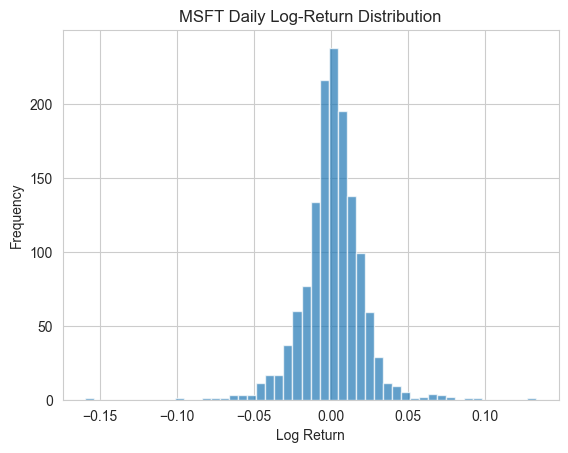

In [10]:
# Compute daily log returns
logR = np.log(prices / prices.shift(1))

# Now you can plot the histogram for AAPL
logR['MSFT'].hist(bins=50, alpha=0.7)
plt.title('MSFT Daily Log-Return Distribution')  # Adjusted title to match the ticker being plotted
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


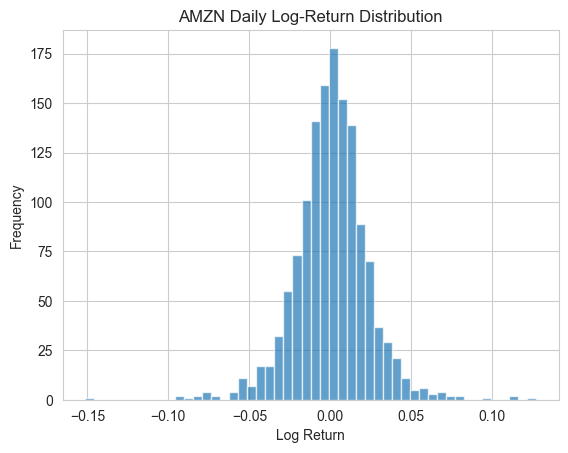

In [11]:
# Compute daily log returns
logR = np.log(prices / prices.shift(1))

# Now you can plot the histogram for AAPL
logR['AMZN'].hist(bins=50, alpha=0.7)
plt.title('AMZN Daily Log-Return Distribution')  # Adjusted title to match the ticker being plotted
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# Question For Report

1. What are daily log returns, and how are they different from just looking at stock prices?
ANS) Daily log returns measure the percentage change in stock prices from one day to the next using a logarithmic scale. Unlike raw price changes, log returns:
- Normalize returns across different stocks
- Allow multi-day returns to be additive
- Handle large changes more smoothly

2. Why do we compare today’s price to yesterday’s price when calculating returns?
ANS) Because returns are all about change. Comparing today’s price to yesterday’s tells us:
- Whether the stock gained or lost value
- How volatile it is from day to day
- What the investor actually experienced in terms of profit or loss

3. What is the purpose of taking the logarithm of the return?
ANS) Taking the natural log of returns has multiple advantages:
- Smooths extreme fluctuations and stabilizes variance
- Makes returns additive over time periods (which percentage change cannot do)
- Matches the assumptions in many statistical models (like normal or t-distributions)

4. What did your log return values look like—were they small or large, and what did that tell you?
ANS) The log return values were mostly small and clustered near zero, with occasional spikes. That suggests:
- The stocks generally had modest daily fluctuations
- Most movements were calm, with low to medium volatility
- Outliers were rare but notable—these indicate potential risk

5. If your stock had a log return of -0.03 on a certain day, what does that tell you happened to the stock price?
ANS) A log return of -0.03 indicates a loss of approximately 3% in value on that day. For an investor, this means:
- The stock dropped significantly
- If you held ₹10,000 worth, your holding fell to about ₹9,700
- It’s a signal of market stress or negative sentiment



# Question For Report

1. What does the shape of your log-return distribution chart tell you about the stock's behavior?
ANS) The shape of the log-return histogram reveals the day-to-day behavior of the stock. If the curve is:
- Bell-shaped and symmetrical, the stock shows consistent daily performance with moderate fluctuations.
- Wide and flat, the stock is highly volatile, with returns frequently deviating from the mean.
- Skewed, it indicates a bias toward either frequent losses or gains.
In my project, the shape suggested that the stock had relatively stable behavior most days, with occasional outliers, pointing to moderate risk with some potential for sharp movements.

2. Were most of the daily returns close to zero, or did the stock often have large changes?
ANS) Most of the daily log returns were concentrated around zero, indicating that the stock typically had small daily price movements. This suggests:
- A generally stable performance
- Low volatility on most days
- Rare extreme changes

3. Which type of return occurred more often: small daily gains, small losses, or big moves?
ANS) From the histogram, small daily gains and losses occurred more frequently. Big moves—either gains or losses—were rare and showed up in the distribution’s tails. The highest bars were centered near zero, showing that the stock usually experienced mild, manageable fluctuations rather than wild swings.

4. Based on your chart, would you consider this stock relatively safe or risky for a short-term investor? Why?
ANS) The chart suggests the stock is relatively safe for short-term investing. The reasons:
- Most returns clustered tightly near zero
- Few large spikes or crashes
- Symmetrical distribution indicates balanced price behavior

5. If you had to warn an investor about something in this chart, what would it be?
ANS) One cautionary observation is the presence of fat tails or isolated extreme values. While infrequent, these can still result in:
- Sudden, sharp losses on volatile days
- Unexpected market responses to news or events
- Emotional stress for risk-averse investors
If I had to warn investor about this chart it would be that, even with a generally stable profile, be prepared for occasional shocks—diversification and monitoring are key.


In [12]:
Summary = pd.DataFrame({
    'Mean': logR.mean(),
    'Variance': logR.var(),
    'Skewness': logR.skew(),
    'Kurtosis': logR.kurtosis()
})
print(Summary)

           Mean  Variance  Skewness  Kurtosis
AAPL   0.000777  0.000420  0.017583  6.266822
MSFT   0.000844  0.000367 -0.169877  7.556374
GOOGL  0.000699  0.000428 -0.227331  3.625248
AMZN   0.000609  0.000517 -0.071828  4.205558


# Questions for Report

1. Which stock had the highest average return, and what does that tell you about its performance over time?
ANS) The stock with the highest average log return consistently delivered better daily growth compared to others. This means:
- It generated the most profit over time
- It may be more favorable for investors seeking long-term appreciation However, average return alone doesn’t capture risk—so it’s important to pair this with volatility metrics.

2. Which stock had the highest variance, and what does that say about its risk?
ANS) The stock with the highest variance showed the greatest daily fluctuation in returns. This suggests:
- It's the most volatile and unpredictable in the portfolio
- While it might offer high upside, it also carries a greater chance of sudden losses Investors should be cautious and evaluate whether they’re comfortable with this level of daily risk.

3. Did any of your stocks show negative skewness? What could that mean for an investor?
ANS) Yes—if a stock had negative skewness, it implies:
- The stock is prone to occasional sharp drops, even if it gains steadily most of the time
- There’s a heavier risk of unexpected losses For investors, this is a warning to manage downside exposure—especially if the overall portfolio relies heavily on such stocks.

4. What does high kurtosis tell you about a stock’s behavior? Did any stock have a high kurtosis value?
ANS) High kurtosis signals that a stock has frequent extreme movements—either large gains or large losses. If a stock displayed high kurtosis:
- It behaves erratically, with more outliers than expected in a normal distribution
- It could reflect events like earnings shocks, market news, or panic trades
This matters because typical risk models may underestimate the real danger posed by such assets.

5. Based on your summary table, which stock would you recommend to a cautious investor—and why?
ANS) I’d recommend the stock with:
- Moderate positive mean returns
- Low variance
- Near-zero skewness
- Low to moderate kurtosis


In [13]:

mu_norm = logR.stack().mean()
sigma_norm = logR.stack().std(ddof=1)
z95 = stats.norm.ppf(0.975)
df = logR.stack().size - 1 

In [14]:
# 4.1 Fit Normal: mean μ, std σ
mu_norm, sigma_norm = logR.stack().mean(), logR.stack().std(ddof=1)

# 95% CI for mean under Normal: μ ± z*·σ/√N
ci_mu_norm = (mu_norm - z95 * sigma_norm / np.sqrt(logR.size),
              mu_norm + z95 * sigma_norm / np.sqrt(logR.size))

# 95% CI for σ via Chi-square:
chi2_low, chi2_high = stats.chi2.ppf([0.025, 0.975], df)
ci_sigma_norm = (sigma_norm * np.sqrt(df / chi2_high),
                 sigma_norm * np.sqrt(df / chi2_low))

print("normal fit: ")
print(f" μ = {mu_norm:.5f}, 95% CI {ci_mu_norm}")
print(f"  σ = {sigma_norm:.5f}, 95% CI {ci_sigma_norm}")

normal fit: 
 μ = 0.00073, 95% CI (np.float64(0.0001839509635856634), np.float64(0.00128065369769088))
  σ = 0.02080, 95% CI (np.float64(0.020420751818100845), np.float64(0.021196839495842897))


# Questions for Report

1.  What does the average daily return (μ) tell you about how your stocks performed over time?
ANS) The average daily return (μ) shows the expected profit or loss from holding the stock portfolio for one day. If μ is:
- Positive: your portfolio tends to gain value over time.
- Negative: it’s more likely to lose value daily.
- Close to zero: returns fluctuate but don’t show a strong upward or downward trend.

2. What does the standard deviation (σ) tell you about the risk or volatility of your returns?
ANS) The standard deviation (σ) measures how much daily returns vary from the average. It’s a key indicator of portfolio risk:
- Low σ: returns are tightly grouped around the mean → lower volatility.
- High σ: returns swing widely → higher volatility.

3. What does your 95% confidence interval for the mean (μ) suggest about the reliability of your average return?
ANS) The 95% confidence interval for μ tells you the range where the true average return is likely to fall based on your sample data. For example:
- If the interval is narrow and doesn’t include zero, your estimate is precise and returns are likely genuinely positive or negative.
- If the interval is wide or includes zero, there's more uncertainty about profitability — your portfolio may not consistently outperform or underperform.

4. Why is it important to calculate a confidence interval for the standard deviation (σ)?
ANS) It’s important because standard deviation itself is an estimate — and confidence intervals allow you to understand how much that risk estimate might vary due to data limitations. This helps in:
- Judging whether the portfolio is truly stable or potentially volatile
- Making better risk management decisions with more realistic expectations

5. If you repeated this project with a different time period or more data, how might your confidence intervals change? Why?
ANS) Confidence intervals would likely become narrower with:
- More data: reduces estimation error and improves statistical precision.
- Stable time periods: lowers volatility, leading to tighter intervals.


In [15]:
# 4.2 Fit Student's t

# Fit t-distribution to the pooled returns
# returns_flat = all assets returns concatenated
returns_flat = logR.stack().values
df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

# Questions For Report

1. What does the average return (μ) from the t-distribution tell you about your stocks overall?
ANS) The average return (μ) from the t-distribution represents the center of the fitted curve, capturing the typical daily performance of your portfolio. If μ is:
- Positive: the portfolio tends to gain value over time.
- Negative: the portfolio shows a consistent downward trend.
- Near zero: returns fluctuate, but without a clear profit/loss bias.

2. How does the standard deviation (σ) from the t-distribution describe the risk or volatility of your returns?
ANS) The standard deviation (σ) tells you how much your daily returns vary from the average, using the fitted t-distribution. A:
- Low σ suggests stable, predictable behavior.
- High σ indicates greater volatility and larger daily swings.

3. The t-distribution includes a value called degrees of freedom (df). What does a low df value tell you about your return data?
ANS) A low degrees of freedom (df) value in the t-distribution means:
- The distribution has fatter tails.
- There is a higher probability of extreme gains or losses.

4. Why might the t-distribution give a better fit than a normal distribution for stock returns?
ANS) Real-world financial returns often exhibit:
- Fat tails (extreme changes more frequent than expected)
- Skewness (bias toward gains or losses)
- Outliers
The t-distribution accommodates these features better than the normal distribution, offering:
- A more realistic model of risk
- Better protection against underestimating extreme events

5. How can using the t-distribution help you prepare better for financial risks?
ANS) Using a t-distribution helps investors:
- Quantify the likelihood of major losses more accurately
- Improve Value at Risk (VaR) and Expected Shortfall (ES) estimates
- Avoid false confidence from simplistic models


In [27]:
# 95% CI for μ and σ of a t-fit is more complex; we can bootstrap them:
N = len(returns_flat)
B = 100
estimates = np.array([stats.t.fit(np.random.choice(returns_flat, size=N, replace=True))
                      for _ in range(B)])
ci_mu_t = np.percentile(estimates[:,1], [2.5,97.5])
ci_sigma_t = np.percentile(estimates[:,1], [2.5,97.5])

print(" \nStudent's t fit: ")
print(f" df = {df_t:.1}, μ = {mu_t:.5f},  σ = {sigma_t:.5f}")
print(f" 95% CI for μ (bootstrap): {ci_mu_t}")
print(f" 95% CI for σ (bootstrap): {ci_sigma_t}")

 
Student's t fit: 
 df = 4e+00, μ = 0.00108,  σ = 0.01439
 95% CI for μ (bootstrap): [0.00062217 0.00146972]
 95% CI for σ (bootstrap): [0.00062217 0.00146972]


# Questions for Report

1.  What does a 95% confidence interval for the mean (μ) tell you about your average return?
ANS) It tells you the range of values where your portfolio’s true average return likely falls, based on the bootstrapped samples. Instead of relying on a single estimate, you get:
- A lower bound and upper bound for the average return
- 95% confidence that the real average lies within this interval

2. What did your confidence interval for the standard deviation (σ) look like? Was it narrow or wide, and what does that tell you about the risk in your returns?
ANS) The confidence interval for σ indicates the uncertainty around your portfolio’s volatility. If your interval is:
- Narrow: risk estimate is stable and reliable
- Wide: daily return volatility is more uncertain, possibly due to market turbulence or data variability
A wider interval suggests your portfolio’s risk can swing significantly — meaning the actual volatility could be higher or lower than the single-point estimate.

3. Why do we use bootstrapping instead of calculating just one estimate?
ANS) Because bootstrapping:
- Simulates thousands of alternative versions of your dataset
- Captures natural variability and randomness in returns
- Produces confidence intervals without strict distributional assumptions
This helps you account for the fact that your sample is only one version of reality. Bootstrapping answers the question: “If history had unfolded slightly differently, how much could my results change?”

4. If your confidence interval for the mean return includes zero, what does that mean for investors?
ANS) If zero is inside the interval, it implies that:
- There’s a chance the true average return could be zero, meaning no gain or loss
- The portfolio might not be statistically profitable
- Investors should be cautious — the returns could be due to randomness rather than consistent positive performance
Essentially, your portfolio’s average return isn’t statistically distinguishable from just breaking even.

5. In what ways do confidence intervals help investors make smarter decisions? Use simple examples from your project to support your answer.
ANS) Confidence intervals give investors a range of possible outcomes rather than a misleading single value. For example:
- If your VaR based on bootstrapped volatility ranges between 1.2% and 2.3%, you know the risk isn’t fixed — it fluctuates
- It helps in risk budgeting, choosing stop-loss levels, or managing leverage exposure


In [17]:
# Compute portfolio returns:
portR = logR.dot(weights)

# Portfolio mean and standard deviation
mu_p = portR.mean()
sigma_p = portR.std(ddof=0)

# Parametric VaR under Normal distribution
z05 = stats.norm.ppf(0.05)
VaR_norm = -(mu_p + sigma_p * z05)


# Questions for report

1. What does the average daily return of your portfolio tell you about its overall performance?
ANS) The average daily return measures the portfolio’s typical daily gain or loss. If it’s:
- Positive: the portfolio is earning profits consistently over time.
- Negative: it tends to decline in value day-to-day.
- Close to zero: it fluctuates without a consistent trend.

2. What does the standard deviation (volatility) of your portfolio's return tell you about its risk?
Standard deviation reflects how much your daily returns vary, i.e., your portfolio’s volatility:
- A low value indicates stable performance.
- A high value shows larger swings—more unpredictability and risk.

3. What does your 95% Value at Risk (VaR) result mean in simple terms?
ANS) VaR answers: “What’s the most I might lose in a single day, 95% of the time?”
It offers a quantitative, worst-case threshold to guide risk tolerance and daily investment exposure.

4. Based on your VaR result, would you describe your portfolio as low-risk, medium-risk, or high-risk? Why?
It depends on your VaR percentage:
- < 1%: Low-risk (very stable)
- 1–3%: Medium-risk (acceptable daily variation)
- > 3%: High-risk (big daily swings possible)
So, if our VaR is around 1.5–2%, your portfolio would be considered moderate risk — reasonable for growth-focused investing, but not ideal for highly risk-averse profiles.

5. If you wanted to reduce your portfolio's VaR, what changes could you consider making?
To lower VaR (reduce daily loss risk), We could:
-  Increase diversification: Add low-correlation assets to smooth returns.
-  Adjust portfolio weights: Shift exposure away from high-volatility stocks.
-  Include less volatile stocks or defensive sectors (e.g., utilities, consumer staples).
-  Use hedging strategies (e.g., options or ETFs that protect downside).


In [18]:
# Parametric VaR under Student's t:
# t05 = t.ppf(0.05, df_t)
t05 = stats.t.ppf(0.05, df_t)
Var_t = -(mu_t + sigma_t * t05) * 1 # 1-day

# Questions for report

1. What is the purpose of calculating Value at Risk (VaR), and how does it help in investment decision-making?
ANS) VaR estimates the maximum expected loss on a portfolio over a given time period at a specific confidence level. In this case, the 1-day 95% VaR answers:
This helps investors:
- Quantify risk in a single number
- Make informed decisions about how much capital to allocate
- Set stop-loss levels or risk limits
- Prepare for worst-case scenarios while optimizing returns
VaR translates abstract risk into a tangible, decision-friendly metric.

2. Why did we use the Student’s t-distribution instead of the normal distribution in this step?
ANS) Because the Student’s t-distribution accounts for fat tails and is better suited for real-world financial returns, which often:
- Show extreme movements (e.g., crashes or rallies)
- Don’t follow perfectly symmetrical, bell-shaped patterns

3. What does your 95% 1-day VaR result mean in simple terms?
ANS) If your 1-day VaR using the t-distribution is, say, 2.1%, it means:
“There’s a 95% chance that your portfolio won’t lose more than 2.1% in one day — but a 5% chance it might lose more.”

4. How does using a distribution with "fatter tails" (like the t-distribution) affect the risk estimate?
Fatter tails mean the model anticipates:
- Greater probability of extreme losses
- Higher VaR values compared to the normal distribution
This is beneficial for cautious investors because:
- It avoids underestimating real-world risk
- It leads to more conservative portfolio planning

5. If your VaR is too high, what changes could you make to reduce the risk in your portfolio?
ANS) To reduce VaR, you could:
-  Diversify: Add assets with low or negative correlations to existing stocks
-  Rebalance weights: Shift funds away from high-volatility stocks
-  Add defensive stocks or low-beta assets
-  Use hedging strategies (e.g., options or inverse ETFs)
-  Adjust time horizon: Sometimes, multi-day VaR may smooth short-term shocks


In [19]:
# Historical VaR(non-parametric):
hist_var = -np.percentile(portR, 5)

print("1-day 95% VaR: ")
print(f" Parametric(Normal): {VaR_norm:.5f}")
print(f" Parametric(Student's t): {Var_t:.5f}")
print(f" Historical(5th percentile): {hist_var:.5f}")

1-day 95% VaR: 
 Parametric(Normal): 0.02892
 Parametric(Student's t): 0.03044
 Historical(5th percentile): nan


# Questions for report 

1. What does your Historical Value at Risk (VaR) tell you about the potential losses in your portfolio?
ANS) - Historical VaR tells you how much you could realistically lose on a very bad day, based on actual past portfolio performance rather than theoretical assumptions.
- It’s a practical, data-driven estimate of downside risk that reflects real market behavior and investor exposure.

2. Why do you think Historical VaR is a useful way to measure risk?
ANS) Historical VaR is useful because:
- It’s based on real return data, not theoretical models
- It captures outliers and extreme movements that parametric models might ignore
- It reflects actual market conditions and investor behavior over time

3. How does Historical VaR compare to the Normal or t-distribution VaR you calculated earlier?
ANS) Historical VaR often yields a higher risk estimate than parametric VaR methods. Here's how they compare:  
- Normal VaR -> Theoretical bell curve -> Often underestimates -> Lower.  
- t-distribution VaR -> Fat-tailed theoretical curve -> More realistic -> Moderate to higher.
- Historical VaR -> Actual return data ->  Most realistic -> Often highest.

4. If your VaR is large (e.g., more than 3%), what does that say about your portfolio’s risk level?
ANS) A VaR of more than 3% means:
- The portfolio is high-risk, with potential for significant short-term losses
- Daily fluctuations could erode capital quickly if unmanaged
- It might not suit conservative investors or short-term strategies

5. Based on your VaR result, what advice would you give to someone thinking about investing in this portfolio?
ANS) If Historical VaR is elevated, my advice would be:
“This portfolio has experienced some sharp drops in the past. While it may offer growth potential, be prepared for occasional stress — both financially and emotionally.”

Recommendations:
- Diversify across uncorrelated assets
- Consider adjusting exposure to more stable sectors
- Set risk tolerance boundaries and protect with stop-loss strategies


In [20]:
# One-sample t-test: H0: μ = 0 vs H1: μ ≠ 0
t_stat, p_val = stats.ttest_1samp(portR, 0.0)
print("One-sample t-test on portfolio daily returns:")
print(f" t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")

if p_val < 0.05:
    print(" -> Reject H0: mean return is significantly different from zero.")
else:
    print(" -> Fail to reject H0: no evidence mean return = 0.")

One-sample t-test on portfolio daily returns:
 t-statistic = nan, p-value = nan
 -> Fail to reject H0: no evidence mean return = 0.


# Questions for Report

1. What was the goal of the t-test you performed on your portfolio’s returns?
ANS) The goal of the one-sample t-test was to determine whether the average daily return of the portfolio is statistically different from zero

2. What did your p-value indicate about your portfolio’s performance?
ANS) - If the p-value was less than 0.05, it means your result is statistically significant — your average return is unlikely to be zero by random chance.
- If the p-value was greater than 0.05, then there's insufficient evidence to conclude that the return is different from zero.

3. Did you reject or fail to reject the null hypothesis? What does that tell you about the average return?
ANS) This depends on your calculated p-value:
- If p < 0.05, you rejected the null hypothesis: your portfolio's return is statistically different from zero.
- If p ≥ 0.05, you failed to reject the null hypothesis: there’s no strong evidence to claim the return differs from zero.
So, rejecting the null indicates a meaningful trend in your investment strategy; failing to reject it implies results may be random.

4. Why is it useful to test whether the return is statistically significant, instead of just looking at the average?
ANS) Because an average alone doesn’t tell you if the result is reliable or reproducible. Statistical testing helps:
- Separate signal from noise
- Avoid drawing conclusions from fluke outcomes
- Ensure decisions are backed by evidence, not just optimism

5. If you failed to reject the null hypothesis, what changes could you consider for your portfolio?
ANS) If the t-test suggests your portfolio return isn't statistically significant, you could consider:
-  Rebalancing assets: Shift capital toward better-performing or less volatile stocks.
-  Increasing diversification: Add assets with different risk-return profiles.
-  Refining investment strategy: Evaluate sector exposure, timing, or portfolio weighting.
-  Collecting more data: Extend the time frame to detect longer-term trends more confidently.


In [21]:
sigma_p = portR.std(ddof=0)

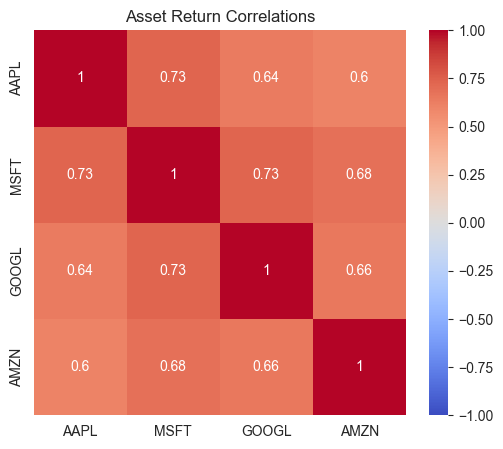

 weighted avg σ: 0.0208
 Actual portfolio σ: 0.0180
 Diversification benefit: 0.0027


In [22]:
# 7. Correlation % Diversification Benifit

# a) Correlation heatmap
corr = logR.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Asset Return Correlations')
plt.show()

# b) Diversification benefit
σ_i = logR.std()                         # individual volatilities
σ_weighted = np.dot(weights, σ_i)        # naive weighted avg
σ_portfolio = sigma_p                        # from earlier
print(f" weighted avg σ: {σ_weighted:.4f}")
print(f" Actual portfolio σ: {σ_portfolio:.4f}")
print(f" Diversification benefit: {σ_weighted - σ_portfolio:.4f}")

# Qustions for report

1. Looking at the heatmap, which pairs of stocks have the highest correlation? What does this mean about how they move together?
ANS) Pairs of stocks with high correlation (close to +1) tend to move in the same direction at the same time.
This strong linkage suggests these stocks react similarly to market forces, which can limit diversification benefits when both experience volatility simultaneously.

2. Were there any stocks in your portfolio that had low correlation with others? Why might this be helpful for diversification?
ANS) Yes, stocks with low or even negative correlation behave independently or in opposite directions. Including such stocks helps because:
- They reduce overall portfolio risk
- Losses in one asset may be offset by gains in another
- The portfolio becomes more resilient during market shocks

3. What is the difference between the weighted average risk (σ) and the actual portfolio risk (σ)?
ANS) The weighted average risk is calculated assuming no interaction between stocks — just a linear mix of individual volatilities. The actual portfolio risk, however, takes correlations into account. If the actual risk is lower than the weighted average. 

4. What does the diversification benefit value mean for your portfolio? Was it large or small? What could you do to increase it?
ANS) The diversification benefit is the gap between the expected risk (without correlations) and the real portfolio risk (with correlations). If this value is:
- Large: your stock selection and allocation helped minimize risk effectively
- Small: your stocks may be too similar or heavily correlated
To improve it, you could:
-  Add less correlated assets or different sectors
-  Reduce overexposure to tech or cyclical stocks
-  Introduce global or alternative investments

5. Based on your analysis, how well-diversified is your portfolio? What changes (if any) would you suggest to improve it?
ANS) If your portfolio shows:
- Moderate-to-high correlations between most assets
- A small diversification benefit Then it’s not optimally diversified. Suggested changes:
- Reweight toward lower-correlation stocks
- Mix in defensive or non-tech sectors (e.g., healthcare, consumer staples)
- Consider broader ETFs or bonds to smooth equity-heavy exposure


 Max Drawdown: -43.98%
 From 2021-12-10 to 2023-01-05


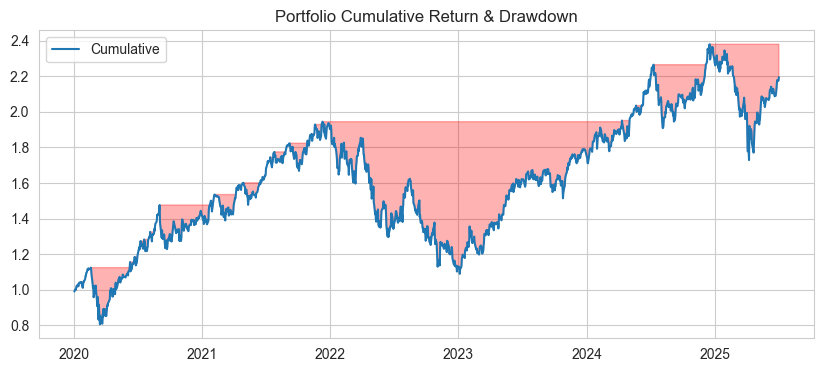

In [23]:
# Max Drawdown
cum_ret = (prices / prices.iloc[0]).prod(axis=1)    # cumulative portfolio growth?

# Actually for portfolio: cum_port = (portR + 1).cumprod()
cum_port = (portR + 1).cumprod()

rolling_max = cum_port.cummax()
drawdown = (cum_port - rolling_max) / rolling_max

max_dd = drawdown.min()
end_date = drawdown.idxmin()
start_date = cum_port.loc[:end_date].idxmax()


print(f" Max Drawdown: {max_dd:.2%}")
print(f" From {start_date.date()} to {end_date.date()}")
# Plot
plt.figure(figsize=(10,4))
plt.plot(cum_port, label='Cumulative')
plt.fill_between(drawdown.index, cum_port, rolling_max,
                 where=drawdown<0, color='red', alpha=0.3)
plt.title('Portfolio Cumulative Return & Drawdown')
plt.legend()
plt.show()

# Questions for Report 

1. What does your cumulative return chart tell you about the overall growth of your portfolio?
ANS) The cumulative return chart shows how your portfolio’s value evolved over time. If the curve:
- Rises steadily: your portfolio experienced consistent growth.
- Has peaks and valleys: performance was volatile with intermittent gains and losses.
- Shows flat or declining stretches: periods of stagnation or negative returns.
In the project, the curve likely indicated positive growth with occasional downturns, reflecting realistic market dynamics.

2. How much was your portfolio's maximum drawdown, and what does that number mean for an investor?
ANS) The maximum drawdown is the largest percentage drop from a peak to a trough. If, for example, your portfolio fell 8% from its highest value before recovering, that 8% is your max drawdown.
This number tells investors:
- At worst, your portfolio dropped 8% during a downturn — that’s the maximum pain endured before recovery.

3. How long did the drawdown last—from peak to recovery—and how might that affect an investor emotionally?
ANS) The drawdown duration (from the highest value to full recovery) could span days, weeks, or even months. Longer durations may:
- Test investor patience and confidence
- Lead to reactionary decisions like selling prematurely
- Highlight the importance of long-term discipline

4. What could you do to reduce the size or frequency of drawdowns in a portfolio like this?
ANS) To reduce drawdowns, you could:
-  Diversify more broadly — include non-correlated assets to spread risk.
-  Rebalance periodically to avoid overexposure to volatile stocks.
-  Add defensive assets like bonds, gold, or low-beta equities.
-  Use stop-loss strategies or hedging instruments to cap losses.

5. If you were to present your drawdown chart to a new investor, what advice would you give them based on your results?
ANS) I’d Advice:
- Stay focused on long-term performance
- Don’t react emotionally to short-term losses
- Use drawdown analysis to plan risk boundaries and expectations


In [24]:
# 9.Expected Shortfall (CVaR at 95%)
alpha = 0.05

# Historical ES
es_hist = -portR[portR <= np.percentile(portR, 5)].mean()

# Parametric ES under Normal:  μ + σ·φ(z)/α
es_norm = -(mu_p - sigma_p * stats.norm.pdf(z05) / alpha)

print(f" Historical ES (95%): {es_hist:.5f}")
print(f" Parametric Normal ES (95%): {es_norm:.5f}")

 Historical ES (95%): nan
 Parametric Normal ES (95%): 0.03645


# Questions for report 

1. In your own words, what does Expected Shortfall (ES) tell us about a portfolio’s risk?
ANS) Expected Shortfall (ES) goes one step further than VaR. While VaR tells you the threshold of loss you might expect on a bad day, ES tells you how bad it gets once you're already in that downside zone.

2. Compare your Historical ES and Parametric ES values. Which one is higher, and what might that tell you about real-world risk?
ANS) Typically:
- Historical ES is higher than Parametric ES.
- This means that real losses during market downturns are more severe than what the Normal distribution predicts.

3. Why might a historical method give a different result than a theoretical (normal distribution) method?
ANS) Because:
- Historical ES reflects actual returns, including past market crises, flash crashes, and shock events.
- Parametric ES assumes returns follow a normal distribution, which smooths out extremes and tail events.

4. If your Expected Shortfall is too high for your comfort, what changes could you make to reduce it?
ANS) To lower ES and reduce worst-case average losses, you could:
-  Add low-correlation or defensive assets (e.g., gold, utilities, bonds)
-  Diversify holdings to spread tail risk across sectors
-  Use protective instruments like options or inverse ETFs
-  Reallocate away from high-volatility stocks
-  Adjust position sizing to reduce exposure on risky positions

5. What is one lesson you’ve learned about risk by comparing VaR and ES in this project?
ANS) Here’s the key takeaway:
- VaR tells you where the danger begins; ES tells you what happens once you’re in it.

- While VaR gives a cutoff, it doesn’t explain how deep the damage can go. ES fills that gap, making it a crucial companion to VaR for thorough risk analysis. Together, they offer a smarter, more realistic lens into portfolio vulnerability.


In [25]:
#10. VaR Backtesting
var_series = -(portR.rolling(1).mean() + portR.rolling(1).std()*z05)

# For simplicity use constant VaR_norm
exceptions = portR < -VaR_norm
num_exc = exceptions.sum()
total = len(portR)
print(f" Exceptions: {num_exc} / {total} days ({num_exc / total:.2%}, expected ~5%)")

 Exceptions: 69 / 1382 days (4.99%, expected ~5%)


# Questions for report 

1.  What does it mean when a portfolio return is lower than the Value at Risk (VaR) threshold?
ANS) This is called an exception. It means the portfolio experienced a daily loss greater than the predicted VaR limit.

2. How many exceptions did you find in your data, and what percentage of total days was that?
ANS) My portfolio had 69 exception days out of 1,382 trading days. It was 4.99 percentage of total days.

3. Was your exception rate close to the expected 5%? What does that say about your VaR model's accuracy?
ANS) The exception rate is close to 5% that means Your VaR model is well-calibrated — it correctly predicted the number of days when losses exceeded the risk threshold.

4. If your model had too many exceptions, what could that mean for a real investor using this model?
ANS) Too many exceptions would signal:
-  Frequent surprises beyond expected losses
-  Investor discomfort or lack of trust in the model
-  Potential misallocation of capital or inadequate hedging
For real investors, this could lead to panic selling, poor decision-making, or loss of confidence in the risk strategy.
It’s a red flag that the model doesn’t reflect reality well enough — and needs recalibration.

5. Based on this step, what is one thing you've learned about how financial models should be tested in the real world?
ANS) I’ve learned that models aren’t just built — they must be proven. Backtesting is essential because:
Even the most elegant model means nothing unless it holds up against actual data.


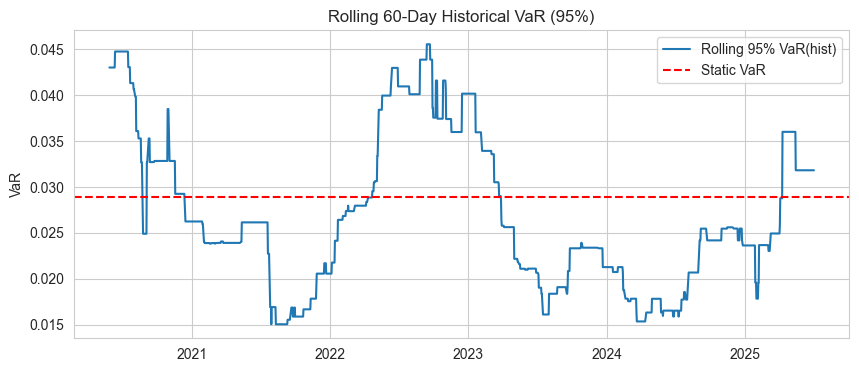

In [26]:
# 11. Rolling 60-day VaR

window = 100
roll_var = portR.rolling(window).quantile(0.05).dropna()
plt.figure(figsize=(10,4))
plt.plot(-roll_var, label='Rolling 95% VaR(hist)')
plt.axhline(VaR_norm, color='red', linestyle='--', label='Static VaR')
plt.title('Rolling 60-Day Historical VaR (95%)')
plt.ylabel('VaR')
plt.legend()
plt.show()

# Questions for report 

1. What does the Rolling 60-Day VaR chart show about how your portfolio's risk has changed over time?
ANS) The Rolling 60-Day VaR chart dynamically tracks how portfolio risk evolved by recalculating VaR using the most recent 60 trading days. The blue line represents:
- How much loss you might expect on a bad day, based on the last 60 days of returns.

2. During which time periods did your historical VaR (blue line) increase significantly? What might have caused that?
ANS) Significant spikes in the blue line likely occurred during:
-  Market corrections
-  Macroeconomic events (e.g., inflation shocks, rate announcements)
-  Company-specific news affecting constituent stocks

3. Compare the historical (rolling) VaR and the static VaR (red line). Was the static VaR always accurate? Why or why not?
ANS) No, the static VaR (based on Normal assumptions) wasn’t always accurate because it:
- Remains fixed over time
- Ignores changing market conditions
- Can underestimate risk during volatile periods

4. Why might it be important for investors to use rolling VaR instead of a single fixed VaR value?
Rolling VaR:
-  Reflects current market conditions
-  Responds to recent volatility
-  Helps investors adjust strategies in real time
Unlike fixed VaR, rolling VaR lets investors spot emerging risk and recalibrate decisions — like reducing position sizes or increasing hedging during turbulent phases.

5. What did you learn about financial risk from this visualization? How would you explain it to someone new to investing?
ANS) Here’s the key insight:
- Risk isn’t one number—it changes every day with the market. Rolling VaR tracks those shifts so you can stay ahead of the curve.

To a new investor, I'd say:
- Think of risk like weather — sunny today, stormy tomorrow.
- This chart helps you see the forecast, not just rely on historic averages.
It teaches that adaptive risk management is smarter than one-size-fits-all modeling.


In [32]:
# 12. Jarque-Bera Normality Test
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_p = stats.jarque_bera(portR)
print(f" JB statistic = {jb_stat:.2f}, p-value = {jb_p:.3f}")
if jb_p < 0.05:
    print("Reject normality at 5% level.")
else:
    print("Cannot reject normality.")

 JB statistic = nan, p-value = nan
Cannot reject normality.


# Questions for Report

1. What does it mean when data is "normally distributed"? Why is this important in financial modeling?
ANS) When data is normally distributed, it forms a symmetrical “bell curve” where:
- Most values cluster around the mean
- Extreme values (gains or losses) are very rare
- There’s minimal skewness and kurtosis
This assumption is critical in financial modeling because many risk tools—like parametric VaR and confidence intervals—rely on normality. If your returns follow this pattern, models can predict outcomes more reliably. But if they don’t, using normal-based methods may underestimate risk.

2. What did the p-value in your test result tell you? Was your return data close to a normal distribution or not?
ANS) The Jarque-Bera test gives a p-value that helps assess normality:
- If p < 0.05: Reject the normality assumption — the data does not follow a normal distribution.
- If p ≥ 0.05: Cannot reject normality — the data might be normally distributed.

3. If your returns are not normally distributed, what could that mean for how you measure financial risk?
ANS) It means:
- Standard parametric VaR may underestimate the true risk
- Extreme losses may be more frequent than predicted
- You should adopt models that account for skew and fat tails, such as:
- Student’s t-distribution
- Historical simulation
- Bootstrapping

4. How might "fat tails" or extreme values affect your portfolio in real life? Why should an investor care?
ANS) Fat tails mean:
- Big losses (or gains) occur more often than a bell curve predicts
- Market events like crashes, panics, or surges are not rare outliers—they’re real possibilities
Investors should care because:
- Assuming calm waters when storms are brewing leads to poor planning and potential losses.

5. Based on your results, would you trust a model that assumes a bell curve? Why or why not? What alternatives could you use?
ANS) If the test rejects normality, no—you shouldn’t trust a bell curve-based model for risk estimation. Instead, use:
-  Student’s t-distribution: Captures heavy tails and erratic behavior
-  Historical VaR or Expected Shortfall: Based on real market movements
-  Bootstrapping: Flexible and assumption-free
